# ADDICTION ANALYSIS REPORT

## Section 1 — Data Understanding and Exploration

### Overview

>This report analyzes the key factors that contribute to addictive behaviors, with a particular focus on smoking and alcohol consumption. It also evaluates how different recovery support systems influence outcomes. The goal is to help healthcare providers identify high-risk populations by examining variables such as age,  mental health indicators, and social support. Insights from this analysis can inform targeted intervention strategies, improve patient recovery outcomes, and support the development of more effective treatment plans.

### Dataset Structure:

> The addiction dataset consists of 3,000 observations and 25 variables representing a diverse patient demographic (ages 15–79). The data includes a mix of geographic, and behavioral metrics, socioeconomic backgrounds and support systems.
It includes both numerical and categorical variables, such as:
- Demographics - name, age, gender, country, city
- Socioeconomic factors - education_level, employment_status, annual_income_usd
- Family and social context - marital_status, children_count
- Behavioral indicators - smokes_per_day, drinks_per_week
- Addiction history - age_started_smoking, age_started_drinking
- Recovery efforts - attempts_to_quit_smoking, attempts_to_quit_drinking

### Main Variables of Interest:

>The primary variables analyzed in this report are:
- Age - to understand how addiction varies across life stages
- Smokes_per_day - to measure smoking intensity
- Drinks_per_week - to measure alcohol consumption levels


### Additional features in the dataset to support investigation into the feature(s) of interest:

> To better explain patterns in addiction, the following variables will also be examined:
- Employment_status – economic stability may influence substance use
- Marital_status – social and emotional support factors
- Age_started_smoking / Age_started_drinking – early exposure risk
- Attempts_to_quit_smoking / Attempts_to_quit_drinking – recovery effort and persistence

In [4]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

# suppress warnings from final output
import warnings
warnings.simplefilter('ignore')

In [5]:
#load the dataset into a dataframe and view a sample of the dataset
addiction_data = pd.read_csv('addiction_data.csv')
addiction_data.sample(10)

,id,name,age,gender,country,city,education_level,employment_status,annual_income_usd,marital_status,...,attempts_to_quit_smoking,attempts_to_quit_drinking,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history
2686,2687,Carlos Smith,67,Other,Congo,South Zachary,NaN,Self-Employed,29586,Divorced,...,2,8,True,Average,Daily,Good,3.9,17.0,NaN,Past
559,560,Martin Torres,76,Female,Russian Federation,Gentryland,College,Retired,91432,Widowed,...,2,0,False,Poor,Daily,Average,7.3,22.9,Strong,Current
1509,1510,Carl Fernandez,57,Other,Nepal,North Kenneth,Primary,Unemployed,28377,Divorced,...,1,4,False,Average,Rarely,Poor,7.7,20.7,Moderate,Past
1580,1581,Robert Wyatt,43,Male,Afghanistan,Port Danielberg,NaN,Self-Employed,36239,Widowed,...,7,0,True,Average,Rarely,Poor,3.0,24.0,NaN,Current
1952,1953,Aaron Garrett,51,Other,Singapore,South Charles,Secondary,Employed,86386,Single,...,1,8,False,Poor,Never,Poor,5.9,22.8,Strong,NaN
1784,1785,Kyle Crawford,48,Male,Saint Martin,Freemanfurt,Primary,Unemployed,134109,Divorced,...,8,1,False,Average,Daily,Average,5.2,10.4,Strong,Current
82,83,Paula Phillips,47,Female,Uzbekistan,South Ryan,High School,Student,142680,Divorced,...,6,4,True,Good,Rarely,Poor,5.8,24.8,NaN,Current
129,130,Dennis Rios,76,Other,Kiribati,Port Vanessa,College,Self-Employed,130387,In a relationship,...,9,9,False,Average,Daily,Good,6.5,29.1,Weak,NaN
2258,2259,Heather Morrow,34,Other,Marshall Islands,New Christopher,Secondary,Retired,30331,Widowed,...,8,2,False,Poor,Rarely,Good,4.9,23.6,Strong,Past
1296,1297,Melissa Hunter,41,Female,Gambia,Lake Michaelbury,High School,Unemployed,151926,Married,...,4,4,False,Average,Daily,Poor,5.4,23.3,Weak,Current


In [6]:
#view the total number of rows and columns of tha dataset
addiction_data.shape

(3000, 25)

In [7]:
#view the entire list of columns in the dataset 
addiction_data.columns

Index(['id', 'name', 'age', 'gender', 'country', 'city', 'education_level',
       'employment_status', 'annual_income_usd', 'marital_status',
       'children_count', 'smokes_per_day', 'drinks_per_week',
       'age_started_smoking', 'age_started_drinking',
       'attempts_to_quit_smoking', 'attempts_to_quit_drinking',
       'has_health_issues', 'mental_health_status', 'exercise_frequency',
       'diet_quality', 'sleep_hours', 'bmi', 'social_support',
       'therapy_history'],
      dtype='object')

In [8]:
#create a copy of the dataset
addiction_copy = addiction_data.copy()

In [9]:
#view the datatypes of the dataset
addiction_copy.dtypes

id                             int64
name                          object
age                            int64
gender                        object
country                       object
city                          object
education_level               object
employment_status             object
annual_income_usd              int64
marital_status                object
children_count                 int64
smokes_per_day                 int64
drinks_per_week                int64
age_started_smoking            int64
age_started_drinking           int64
attempts_to_quit_smoking       int64
attempts_to_quit_drinking      int64
has_health_issues               bool
mental_health_status          object
exercise_frequency            object
diet_quality                  object
sleep_hours                  float64
bmi                          float64
social_support                object
therapy_history               object
dtype: object

In [10]:
#check for null values in dataset
addiction_copy.isnull().sum()

id                              0
name                            0
age                             0
gender                          0
country                         0
city                            0
education_level               420
employment_status               0
annual_income_usd               0
marital_status                  0
children_count                  0
smokes_per_day                  0
drinks_per_week                 0
age_started_smoking             0
age_started_drinking            0
attempts_to_quit_smoking        0
attempts_to_quit_drinking       0
has_health_issues               0
mental_health_status            0
exercise_frequency              0
diet_quality                    0
sleep_hours                     0
bmi                             0
social_support                753
therapy_history              1014
dtype: int64

In [11]:
#view the distribution of values for the numeric columns
addiction_copy.describe()

,id,age,annual_income_usd,children_count,smokes_per_day,drinks_per_week,age_started_smoking,age_started_drinking,attempts_to_quit_smoking,attempts_to_quit_drinking,sleep_hours,bmi
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,46.654333,98904.178000,2.453667,10.034000,5.002333,24.365667,24.525333,4.440333,4.542000,6.470400,25.170133
std,866.169729,18.740880,57288.035963,1.704354,3.108386,2.214037,8.707309,8.679121,2.835334,2.866992,1.495878,5.013345
min,1.000000,15.000000,560.000000,0.000000,2.000000,0.000000,10.000000,10.000000,0.000000,0.000000,1.500000,9.100000
25%,750.750000,31.000000,49336.000000,1.000000,8.000000,3.000000,17.000000,17.000000,2.000000,2.000000,5.475000,21.900000
50%,1500.500000,47.000000,98616.500000,2.000000,10.000000,5.000000,24.000000,25.000000,4.000000,5.000000,6.500000,25.200000
75%,2250.250000,63.000000,148622.750000,4.000000,12.000000,6.000000,32.000000,32.000000,7.000000,7.000000,7.500000,28.400000
max,3000.000000,79.000000,199951.000000,5.000000,21.000000,14.000000,39.000000,39.000000,9.000000,9.000000,12.600000,43.900000


### Initial observations
1. The minimum bmi value of 9.1 is far below the healthy range recommended by medical professionals to be 18.5, indicating a likely data entry error or outlier.

2. A minimum starting age of 10 compared to a mean age of 24 reflects a high variability of ages in the dataset which is also confirmed by the high standard deviation value.

3. The large gap between the minimum annual income $560 and mean - 98,904 suggests extreme outliers or possible data inconsistencies as it is almost impossible for a household to live on that income for a year.
                                                             

## Section 2 — Data Cleaning and Validation

#### 2.1 Smokes_per_day is converted to smokes_per_week

To ensure consistency in analysis, smokes_per_day is converted to a weekly measure by multiplying by 7, allowing for a standardized and more accurate comparison between both variables (smokes_per_day and drinks_per_week).

In [15]:
#create a new column smokes_per_week 
addiction_copy['smokes_per_week'] = addiction_copy['smokes_per_day'] * 7

#### 2.2 Handling unrealistic BMI values
The recommended minimum bmi for a human is 18.5, but the minium on the dataset shows 9. All bmi values lower than 15 will be replaced by the mean of the BMI of the dataset to reduce the impact of potential data errors.

In [17]:
#validate the bmi logic
bmi_logic = addiction_copy[addiction_copy['bmi'] < 15][['id', 'name', 'age', 'bmi']]

print(bmi_logic)

        id             name  age   bmi
25      26      Susan Costa   61  10.4
183    184  Felicia Navarro   25  14.5
191    192      Megan Wiley   74  13.2
215    216    Monica Turner   47  13.6
264    265     Amanda Moore   38  12.3
...    ...              ...  ...   ...
2709  2710     Samuel Jones   73  14.3
2721  2722     Glenn Farmer   55   9.1
2922  2923   Candice Brooks   18  12.0
2932  2933  Lawrence Thomas   57  14.6
2948  2949  Elizabeth Evans   59  11.9

[62 rows x 4 columns]


In [18]:
# Compute mean of valid BMI
mean_bmi = addiction_copy.loc[addiction_copy['bmi'] >= 15, 'bmi'].mean()

#Replace invalid BMI values
addiction_copy.loc[addiction_copy['bmi'] < 15, 'bmi'] = mean_bmi

#### 2.3 Handling missing categorical data
Missing values in the categorical columns (education_level, social_support, and therapy_history) are replaced with “Unavailable” to preserve the dataset structure and ensure consistency during analysis.

In [20]:
# List of categorical columns to update
categorical_cols = ['education_level', 'social_support', 'therapy_history']

# Replace NaN/Null with 'Unavailable'
addiction_copy[categorical_cols] = addiction_copy[categorical_cols].fillna('Unavailable')

# Verify the fix
print(addiction_copy[categorical_cols].isnull().sum())

education_level    0
social_support     0
therapy_history    0
dtype: int64


#### 2.4 Inconsistent age values
Some records show age_started_smoking or age_started_drinking greater than the current age which is logically impossible. These inconsistencies will be treated as data errors and replaced with their current age to maintain data integrity.

In [22]:
#validate the age_started_smoking logic
age_logic = addiction_copy[addiction_copy['age'] < addiction_copy['age_started_smoking']][['id', 'name', 'age', 'age_started_smoking']]

print(age_logic)

        id              name  age  age_started_smoking
3        4   Michael Mathews   35                   37
17      18       Brian Brown   36                   37
22      23      Chad Bennett   29                   33
30      31     Steven Austin   17                   30
36      37  Darrell Thompson   18                   26
...    ...               ...  ...                  ...
2985  2986        Yvette Lee   19                   39
2987  2988  Kristina Mercado   18                   29
2990  2991        Renee Rios   22                   36
2995  2996     Mary Bartlett   29                   33
2997  2998       Megan Duffy   15                   27

[462 rows x 4 columns]


In [23]:
# Fix Smoking age: If Age Started > Current Age, set it to Current Age
addiction_copy.loc[addiction_copy['age_started_smoking'] > addiction_copy['age'], 'age_started_smoking'] = addiction_copy['age']

In [24]:
#validate the changes
age_logic = addiction_copy[addiction_copy['age'] < addiction_copy['age_started_smoking']][['id', 'name', 'age', 'age_started_smoking']]

print(age_logic)

Empty DataFrame
Columns: [id, name, age, age_started_smoking]
Index: []


In [25]:
#validate the age logic with age started drinking
age_logic = addiction_copy[addiction_copy['age'] < addiction_copy['age_started_drinking']][['id', 'name', 'age', 'age_started_drinking']]

print(age_logic)

        id                name  age  age_started_drinking
5        6      Carrie Sellers   17                    35
8        9      Melanie Walker   16                    36
11      12  Michael Parker DDS   16                    24
22      23        Chad Bennett   29                    33
32      33     Annette Edwards   21                    33
...    ...                 ...  ...                   ...
2986  2987     Linda Rodriguez   35                    38
2987  2988    Kristina Mercado   18                    39
2990  2991          Renee Rios   22                    39
2992  2993         Amanda Ryan   33                    39
2997  2998         Megan Duffy   15                    19

[505 rows x 4 columns]


In [26]:
# Fix Drinking: If Age Started > Current Age, set it to Current Age
addiction_copy.loc[addiction_copy['age_started_drinking'] > addiction_copy['age'], 'age_started_drinking'] = addiction_copy['age']

In [27]:
#validate the changes
age_logic = addiction_copy[addiction_copy['age'] < addiction_copy['age_started_drinking']][['id', 'name', 'age', 'age_started_drinking']]

print(age_logic)

Empty DataFrame
Columns: [id, name, age, age_started_drinking]
Index: []


#### 2.5 Validate health status for high bmi
Individuals with a BMI over 40 are classified as morbidly obese, placing them at higher risk for Type II Diabetes and heart disease. 

In [29]:
# Filter the dataframe
result = addiction_copy[
    (addiction_copy['has_health_issues'] == False) & 
    (addiction_copy['bmi'] > 40)
][['id', 'name', 'has_health_issues', 'bmi']]

# Display the result
result

,id,name,has_health_issues,bmi
2085,2086,Anthony Adams,False,40.6
2688,2689,Jessica Collins,False,41.5


> These records should be flagged as high-risk patients with further health checks to ensure appropriate monitoring of their health status.

#### 2.6 Create age group column
A new age group column will be created to categorize individuals into ranges. This allows for easier analysis of addiction patterns across different life stages.

In [32]:
#group age into bins
bins = [0, 17, 25, 35, 50, 65, np.inf]
labels = ['less than 18', '18-25', '26-35', '36-50', '51-65', '65+']

addiction_copy['age_group'] = pd.cut(addiction_copy['age'], bins=bins, labels=labels)

print(addiction_copy[['age', 'age_group']].sample(10))

      age age_group
1116   62     51-65
2855   23     18-25
2413   59     51-65
111    29     26-35
487    75       65+
417    75       65+
722    19     18-25
1100   30     26-35
1962   39     36-50
2279   60     51-65


#### 2.7 Create annual income group column
A new annual income group column will be created to categorize income into ranges. 

In [34]:
#create income bins
income_bins = [0, 30000, 60000, 90000, 120000, 150000, 180000, np.inf]

# Define the labels for these increments
income_labels = ['<30k', '30k-60k', '60k-90k', '90k-120k', '120k-150k', '150k-180k', '180k+']

# Create the new column
addiction_copy['income_group'] = pd.cut( addiction_copy['annual_income_usd'], 
    bins=income_bins, 
    labels=income_labels, 
    right=False)

#Check the results
print(addiction_copy['income_group'].value_counts().sort_index())

income_group
<30k         461
30k-60k      437
60k-90k      469
90k-120k     451
120k-150k    455
150k-180k    466
180k+        261
Name: count, dtype: int64


#### 2.8 Validate income of unemployed persons or students 

Records where employment_status is “unemployed” or “student” but annual_income_usd greater than $100,000 are unusual and may indicate data entry errors or outliers.

In [36]:
# Filter the dataframe
result = addiction_copy[
    (addiction_copy['employment_status'].isin(['Unemployed', 'Student'])) & 
    (addiction_copy['annual_income_usd'] >= 100000)
][['id', 'name', 'employment_status', 'annual_income_usd']]

# Display the result
result

,id,name,employment_status,annual_income_usd
2,3,Steven Little,Unemployed,162480
13,14,Kristin Nelson,Student,138186
15,16,Robert Vasquez,Unemployed,175456
16,17,Clinton Johnson,Student,148536
17,18,Brian Brown,Student,169298
...,...,...,...,...
2975,2976,Dr. Brian Mendez,Unemployed,107541
2979,2980,Marie Pearson,Student,192650
2984,2985,Gavin Chambers,Unemployed,175173
2989,2990,Katherine Bryant,Unemployed,151600


> These data points should be validated at the point of data entry to ensure data integrity and improve subsequent analysis.

## Section 3 — Data Exploration

## 3.1 Demographic Analysis

#### Demographic Analysis by Age Group

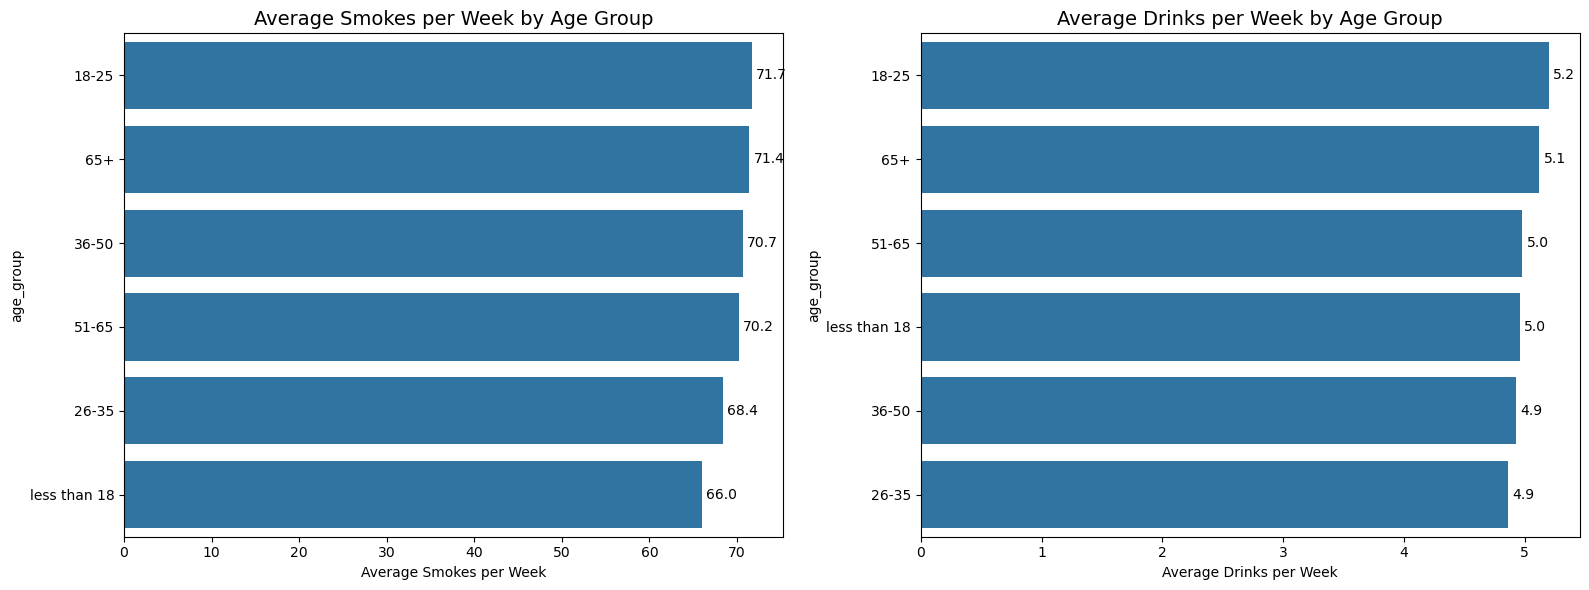

In [41]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
base_color = sb.color_palette()[0]

# Calculate the order based on average smoking intensity
smoke_order = addiction_copy.groupby('age_group')['smokes_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='age_group', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    errorbar=None
)

# Adding Data Labels for Smoking
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)
    
axes[0].set_title('Average Smokes per Week by Age Group', fontsize=14)
axes[0].set_ylabel('age_group')
axes[0].set_xlabel('Average Smokes per Week')

# Calculate the order based on average drinking intensity
drink_order = addiction_copy.groupby('age_group')['drinks_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='age_group', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    errorbar=None
)

# Adding Data Labels for Drinking
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)
    
axes[1].set_title('Average Drinks per Week by Age Group', fontsize=14)
axes[1].set_ylabel('age_group')
axes[1].set_xlabel('Average Drinks per Week')
plt.tight_layout()
plt.show()

> These charts indicate that individuals in the 18–25 and 65+ age groups exhibit the highest levels of smoking and drinking per week, highlighting these groups as key targets for mental health services or further study.

#### Demographic Analysis by Gender

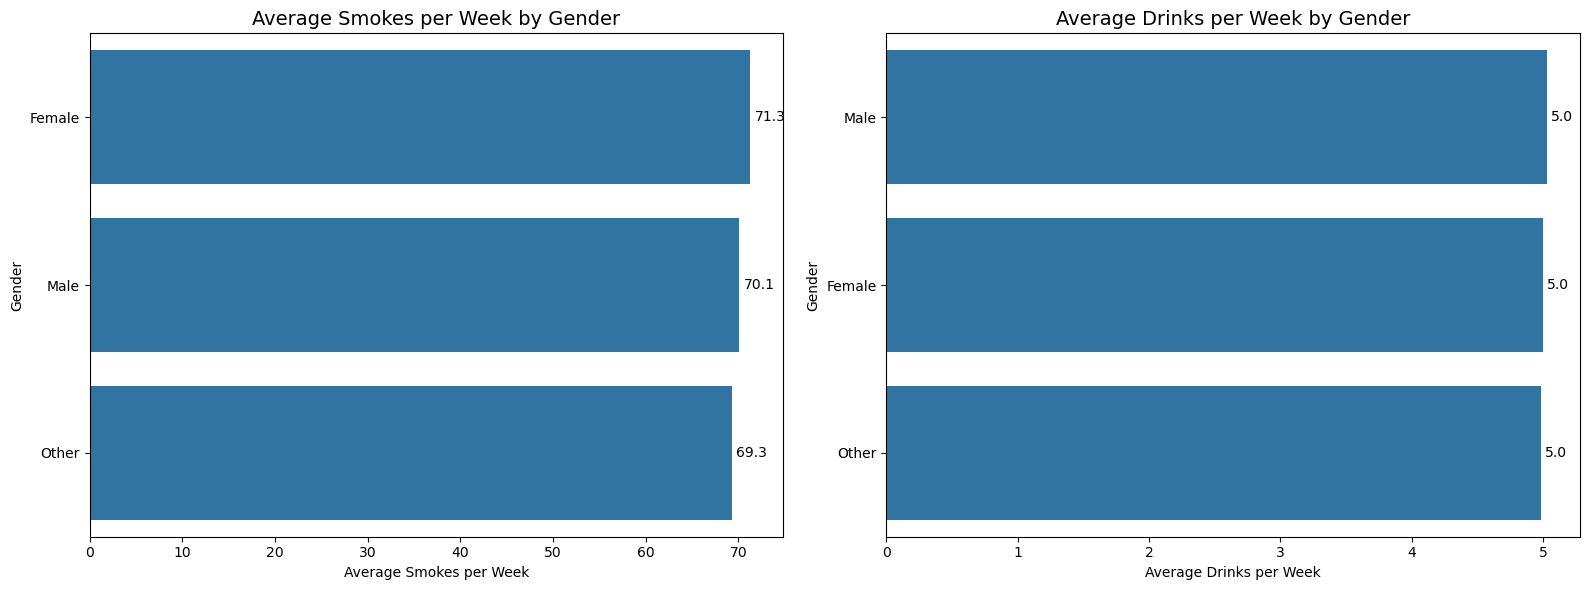

In [44]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
base_color = sb.color_palette()[0]

# Calculate the order based on average smoking intensity
smoke_order = addiction_copy.groupby('gender')['smokes_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='gender', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    errorbar=None
)

# Adding Data Labels for Smoking
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)
    
axes[0].set_title('Average Smokes per Week by Gender', fontsize=14)
axes[0].set_ylabel('Gender')
axes[0].set_xlabel('Average Smokes per Week')

# --- PLOT 2: Average Drinks per Week 
# Calculate the order based on average drinking intensity
drink_order = addiction_copy.groupby('gender')['drinks_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='gender', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    errorbar=None
)

# Adding Data Labels for Drinking
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)
    
axes[1].set_title('Average Drinks per Week by Gender', fontsize=14)
axes[1].set_ylabel('Gender')
axes[1].set_xlabel('Average Drinks per Week')
plt.tight_layout()
plt.show()

> These charts show that females have higher average smoking habits, while average drinking habits are similar across all genders.

#### Demographic Analysis by Education level

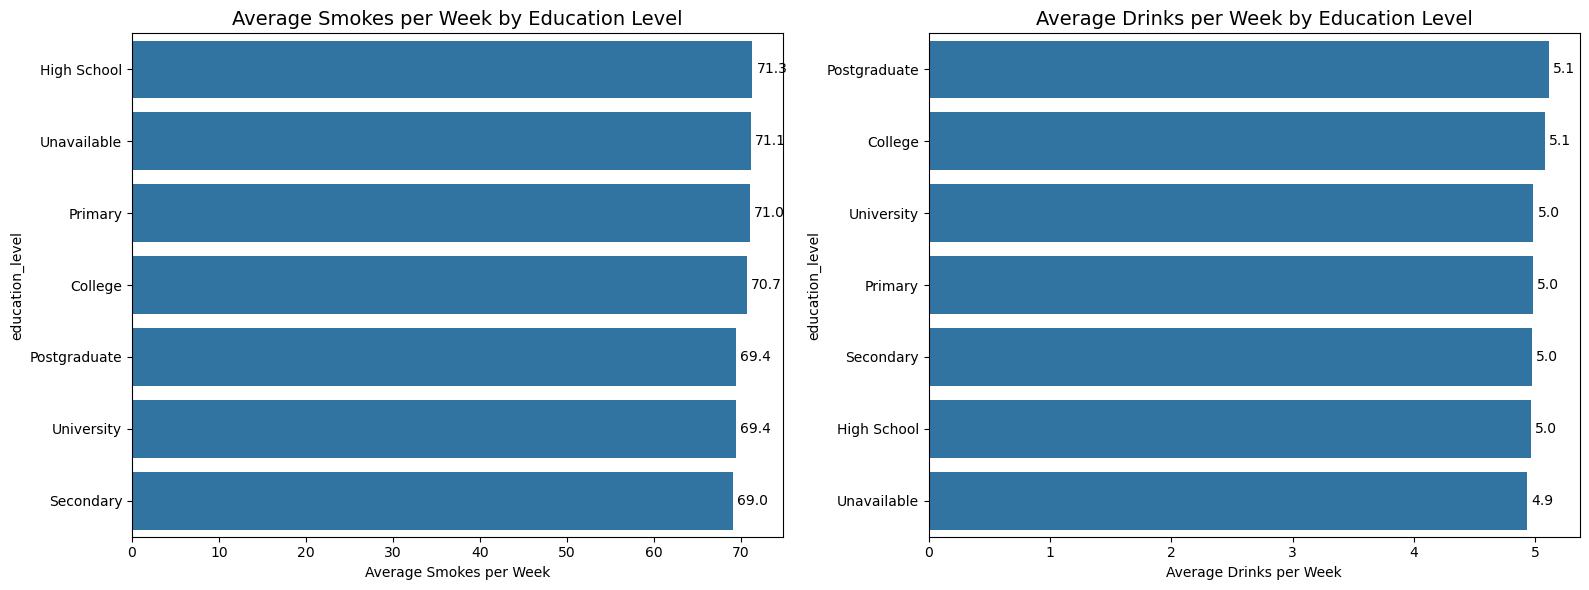

In [47]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
base_color = sb.color_palette()[0]

# --- PLOT 1: Average Smokes per Week
# Calculate the order based on average smoking intensity
smoke_order = addiction_copy.groupby('education_level')['smokes_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='education_level', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    errorbar=None
)

# Adding Data Labels for Smoking
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)
    
axes[0].set_title('Average Smokes per Week by Education Level', fontsize=14)
axes[0].set_ylabel('education_level')
axes[0].set_xlabel('Average Smokes per Week')

# --- PLOT 2: Average Drinks per Week
# Calculate the order based on average drinking intensity
drink_order = addiction_copy.groupby('education_level')['drinks_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='education_level', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    errorbar=None
)

# Adding Data Labels for Drinking
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)
    
axes[1].set_title('Average Drinks per Week by Education Level', fontsize=14)
axes[1].set_ylabel('education_level')
axes[1].set_xlabel('Average Drinks per Week')
plt.tight_layout()
plt.show()

> These charts reveal that high school graduates exhibit the highest smoking rates, whereas college and postgraduate graduates show the highest drinking rates with moderate smoking levels.

#### Demographic Analysis by Employment status

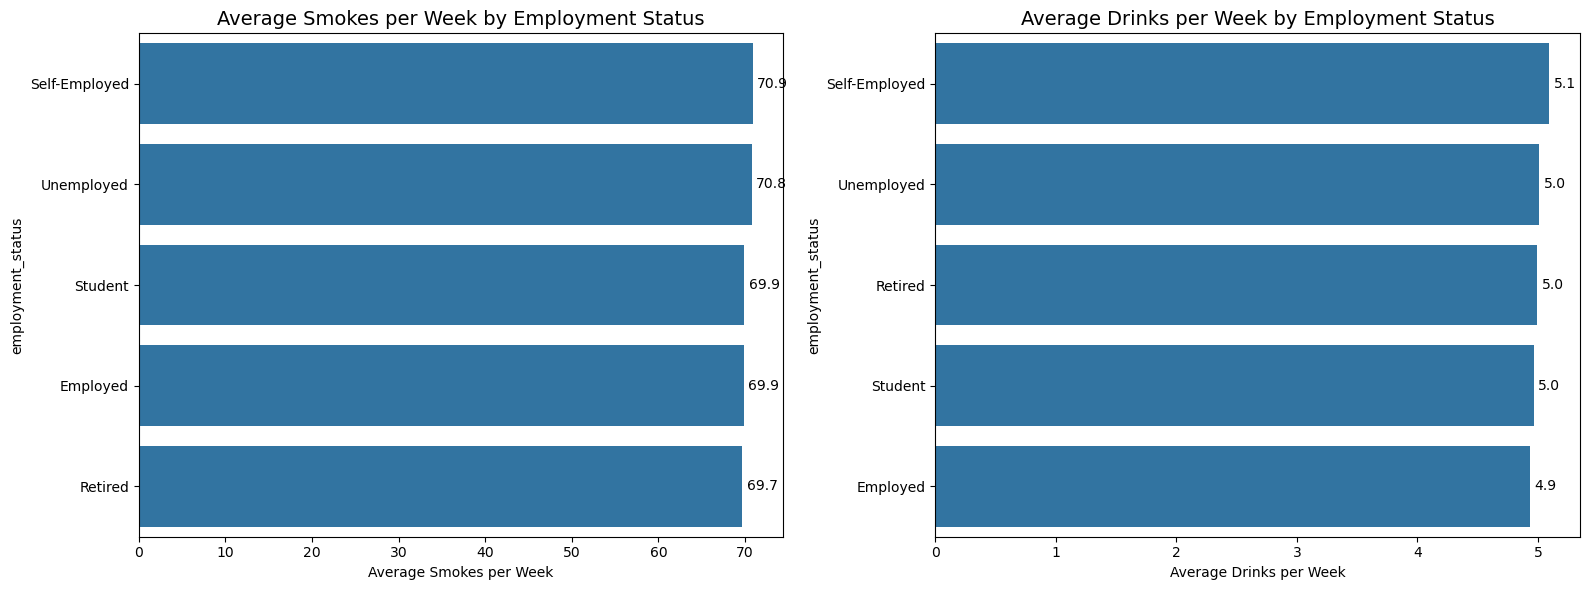

In [50]:
# 2. Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
base_color = sb.color_palette()[0]

# --- PLOT 1: Average Smokes per Week 
# Calculate the order based on average smoking intensity
smoke_order = addiction_copy.groupby('employment_status')['smokes_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='employment_status', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    errorbar=None
)

# Adding Data Labels for Smoking
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)
    
axes[0].set_title('Average Smokes per Week by Employment Status', fontsize=14)
axes[0].set_ylabel('employment_status')
axes[0].set_xlabel('Average Smokes per Week')

# --- PLOT 2: Average Drinks per Week
# Calculate the order based on average drinking intensity
drink_order = addiction_copy.groupby('employment_status')['drinks_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='employment_status', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    errorbar=None
)

# Adding Data Labels for Drinking
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)
    
axes[1].set_title('Average Drinks per Week by Employment Status', fontsize=14)
axes[1].set_ylabel('employment_status')
axes[1].set_xlabel('Average Drinks per Week')
plt.tight_layout()
plt.show()

> These charts indicate that self-employed individuals have the highest average smoking and drinking habits compared to other employment groups.

## 3.2 Geographic Pattern

#### Geographic Analysis by Country

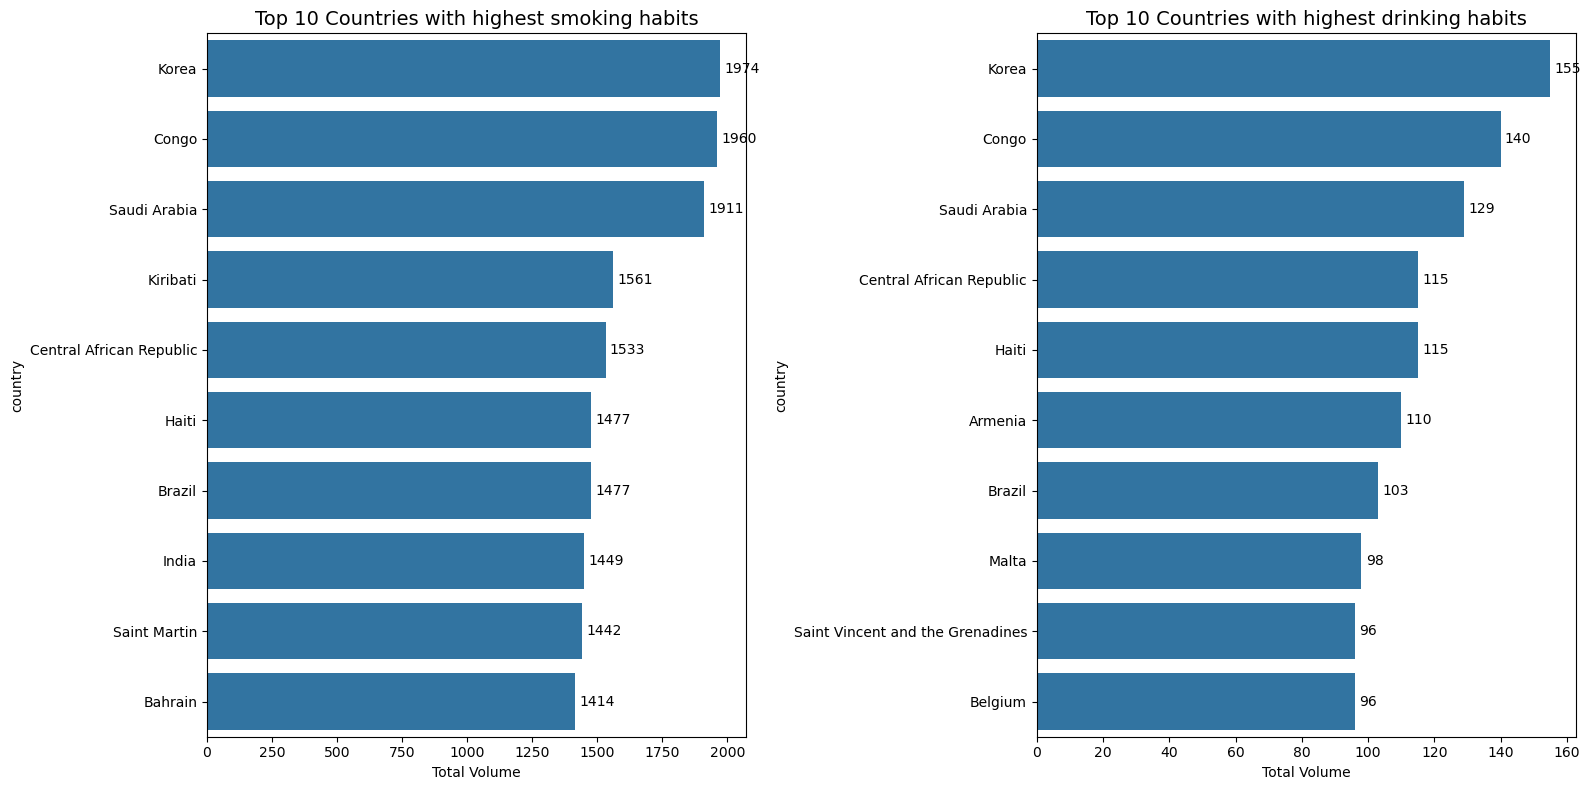

In [54]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
base_color = sb.color_palette()[0]

# --- PLOT 1: TOTAL Smokes per Week (Top 10 Countries) ---
smoke_totals = addiction_copy.groupby('country')['smokes_per_week'].sum().sort_values(ascending=False).head(10)
smoke_order = smoke_totals.index

sb.barplot(
    data=addiction_copy[addiction_copy['country'].isin(smoke_order)], 
    y='country', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    estimator='sum',
    errorbar=None
)

# Adding Data Labels
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3)
axes[0].set_title('Top 10 Countries with highest smoking habits', fontsize=14)
axes[0].set_xlabel('Total Volume')

# --- PLOT 2: TOTAL Drinks per Week (Top 10 Countries) ---
drink_totals = addiction_copy.groupby('country')['drinks_per_week'].sum().sort_values(ascending=False).head(10)
drink_order = drink_totals.index

sb.barplot(
    data=addiction_copy[addiction_copy['country'].isin(drink_order)], 
    y='country', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    estimator='sum', 
    errorbar=None
)

# Adding Data Labels
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3)
axes[1].set_title('Top 10 Countries with highest drinking habits', fontsize=14)
axes[1].set_xlabel('Total Volume')
plt.tight_layout()
plt.show()

> These charts indicate that Korea, followed by Congo and Saudi Arabia, consistently have the highest total consumption of both alcohol and cigarettes.

#### Geographic Analysis by City

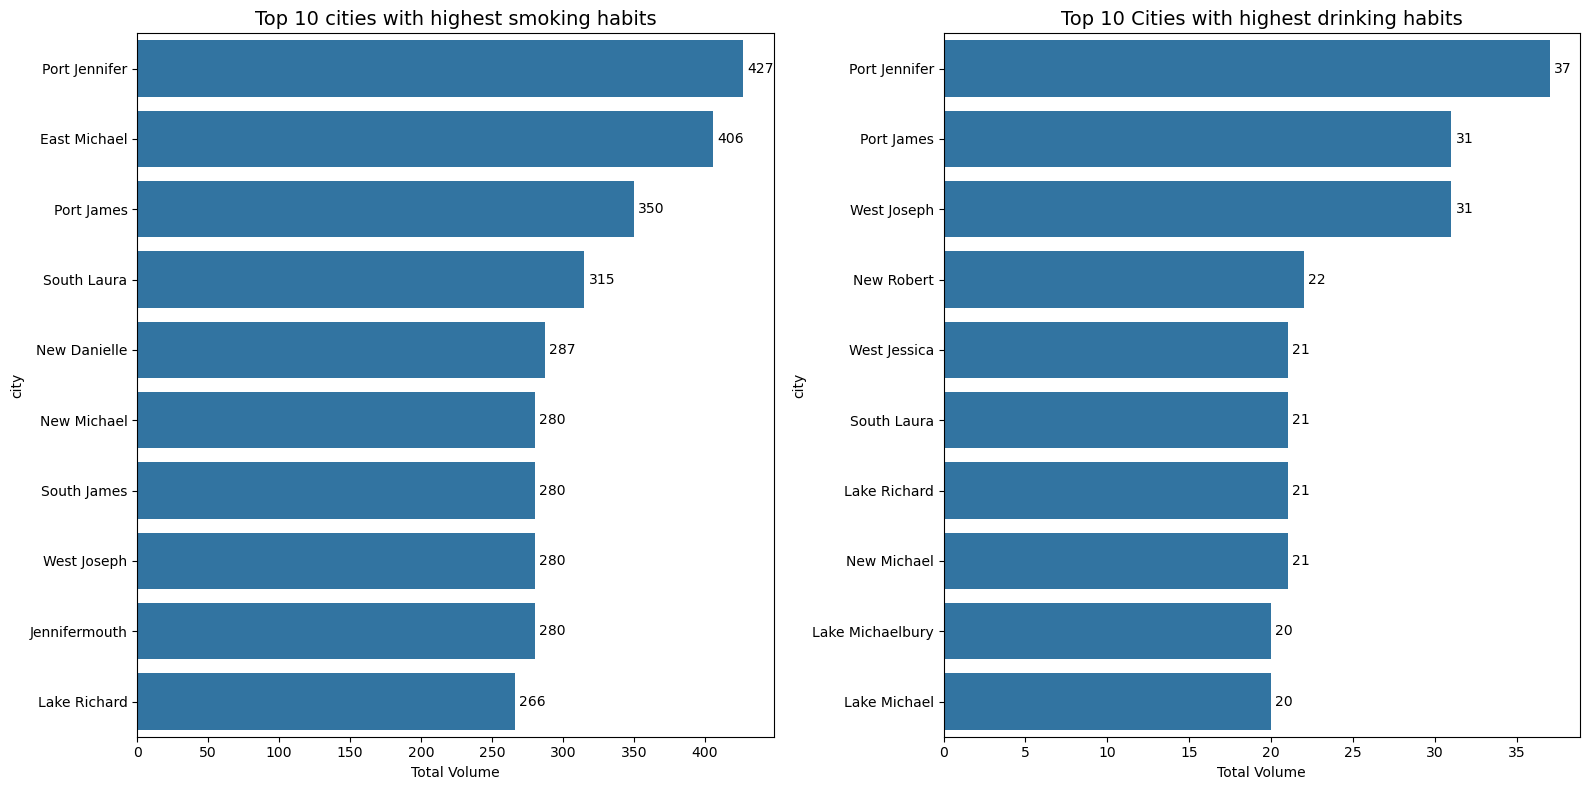

In [57]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
base_color = sb.color_palette()[0]

# --- PLOT 1: TOTAL Smokes per Week (Top 10 Countries) ---
smoke_totals = addiction_copy.groupby('city')['smokes_per_week'].sum().sort_values(ascending=False).head(10)
smoke_order = smoke_totals.index

sb.barplot(
    data=addiction_copy[addiction_copy['city'].isin(smoke_order)], 
    y='city', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    estimator='sum', 
    errorbar=None
)

# Adding Data Labels
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3)
axes[0].set_title('Top 10 cities with highest smoking habits', fontsize=14)
axes[0].set_xlabel('Total Volume')

# --- PLOT 2: TOTAL Drinks per Week (Top 10 Countries) ---
drink_totals = addiction_copy.groupby('city')['drinks_per_week'].sum().sort_values(ascending=False).head(10)
drink_order = drink_totals.index

sb.barplot(
    data=addiction_copy[addiction_copy['city'].isin(drink_order)], 
    y='city', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    estimator='sum',
    errorbar=None
)

# Adding Data Labels
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3)
axes[1].set_title('Top 10 Cities with highest drinking habits', fontsize=14)
axes[1].set_xlabel('Total Volume')
plt.tight_layout()
plt.show()

> These charts show Port Jennifer as the city with the highest alcohol and cigarette consumption, while Port James ranks third for smoking and second for drinking.

## 3.3 Income and Addiction

#### Income Group vs Substance Abuse

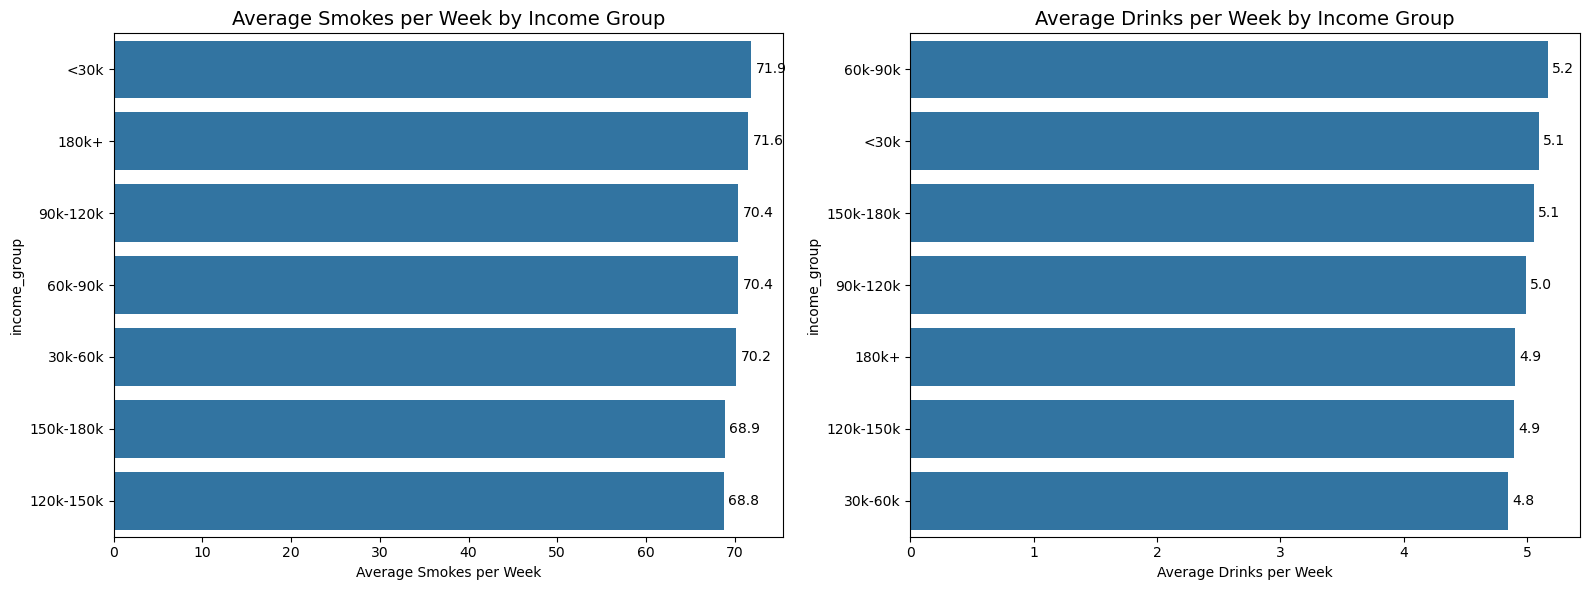

In [61]:
# 2. Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
base_color = sb.color_palette()[0]

# --- PLOT 1: Average Smokes per Week (Sorted) ---
# Calculate the order based on average smoking intensity
smoke_order = addiction_copy.groupby('income_group')['smokes_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='income_group', 
    x='smokes_per_week', 
    ax=axes[0], 
    color=base_color, 
    order=smoke_order,
    errorbar=None
)

# Adding Data Labels for Smoking
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)
    
axes[0].set_title('Average Smokes per Week by Income Group', fontsize=14)
axes[0].set_ylabel('income_group')
axes[0].set_xlabel('Average Smokes per Week')

# --- PLOT 2: Average Drinks per Week (Sorted) ---
# Calculate the order based on average drinking intensity
drink_order = addiction_copy.groupby('income_group')['drinks_per_week'].mean().sort_values(ascending=False).index

sb.barplot(
    data=addiction_copy, 
    y='income_group', 
    x='drinks_per_week', 
    ax=axes[1], 
    color=base_color,
    order=drink_order,
    errorbar=None
)

# Adding Data Labels for Drinking
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)
    
axes[1].set_title('Average Drinks per Week by Income Group', fontsize=14)
axes[1].set_ylabel('income_group')
axes[1].set_xlabel('Average Drinks per Week')
plt.tight_layout()
plt.show()

> Individuals earning less than $30K annually exhibit the highest smoking habits and the second-highest drinking habits, while those earning 120K–150K show the lowest smoking habits and the second-lowest drinking habits.

#### Relationship between Annual Income vs Substance Abuse(smoking and drinking habits)

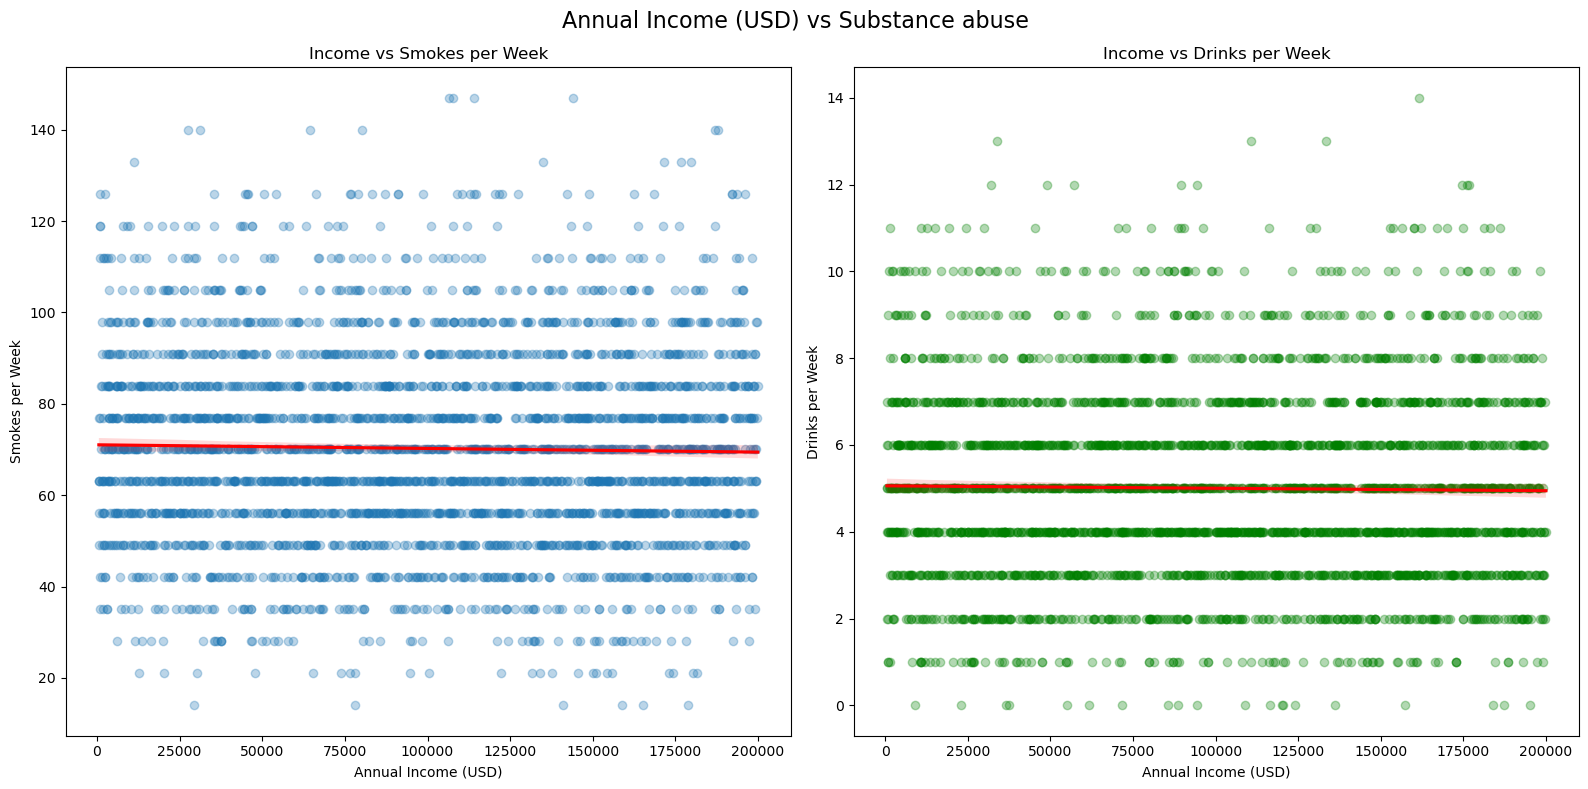

In [64]:
# Setup the figure for two plots side-by-side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Annual Income (USD) vs Substance abuse', fontsize=16)

# --- PLOT 1: Income vs Smokes per Week ---
sb.regplot(
    data=addiction_copy,
    x='annual_income_usd',
    y='smokes_per_week',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=axes[0]  # Corrected to a single index
)
axes[0].set_title('Income vs Smokes per Week')
axes[0].set_xlabel('Annual Income (USD)')
axes[0].set_ylabel('Smokes per Week')

# --- PLOT 2: Income vs Drinks per Week ---
sb.regplot(
    data=addiction_copy,
    x='annual_income_usd',
    y='drinks_per_week',
    scatter_kws={'alpha': 0.3, 'color': 'green'},
    line_kws={'color': 'red'},
    ax=axes[1]  # Corrected to a single index
)
axes[1].set_title('Income vs Drinks per Week')
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Drinks per Week')
plt.tight_layout()
plt.show()

> The analysis shows that annual income has a weak correlation with smoking or drinking frequency, as indicated by the flat regression lines.

## 3.4 Lifestyle Factors

#### Analysis between exercise frequency, diet quality vs smoking and drinking habits

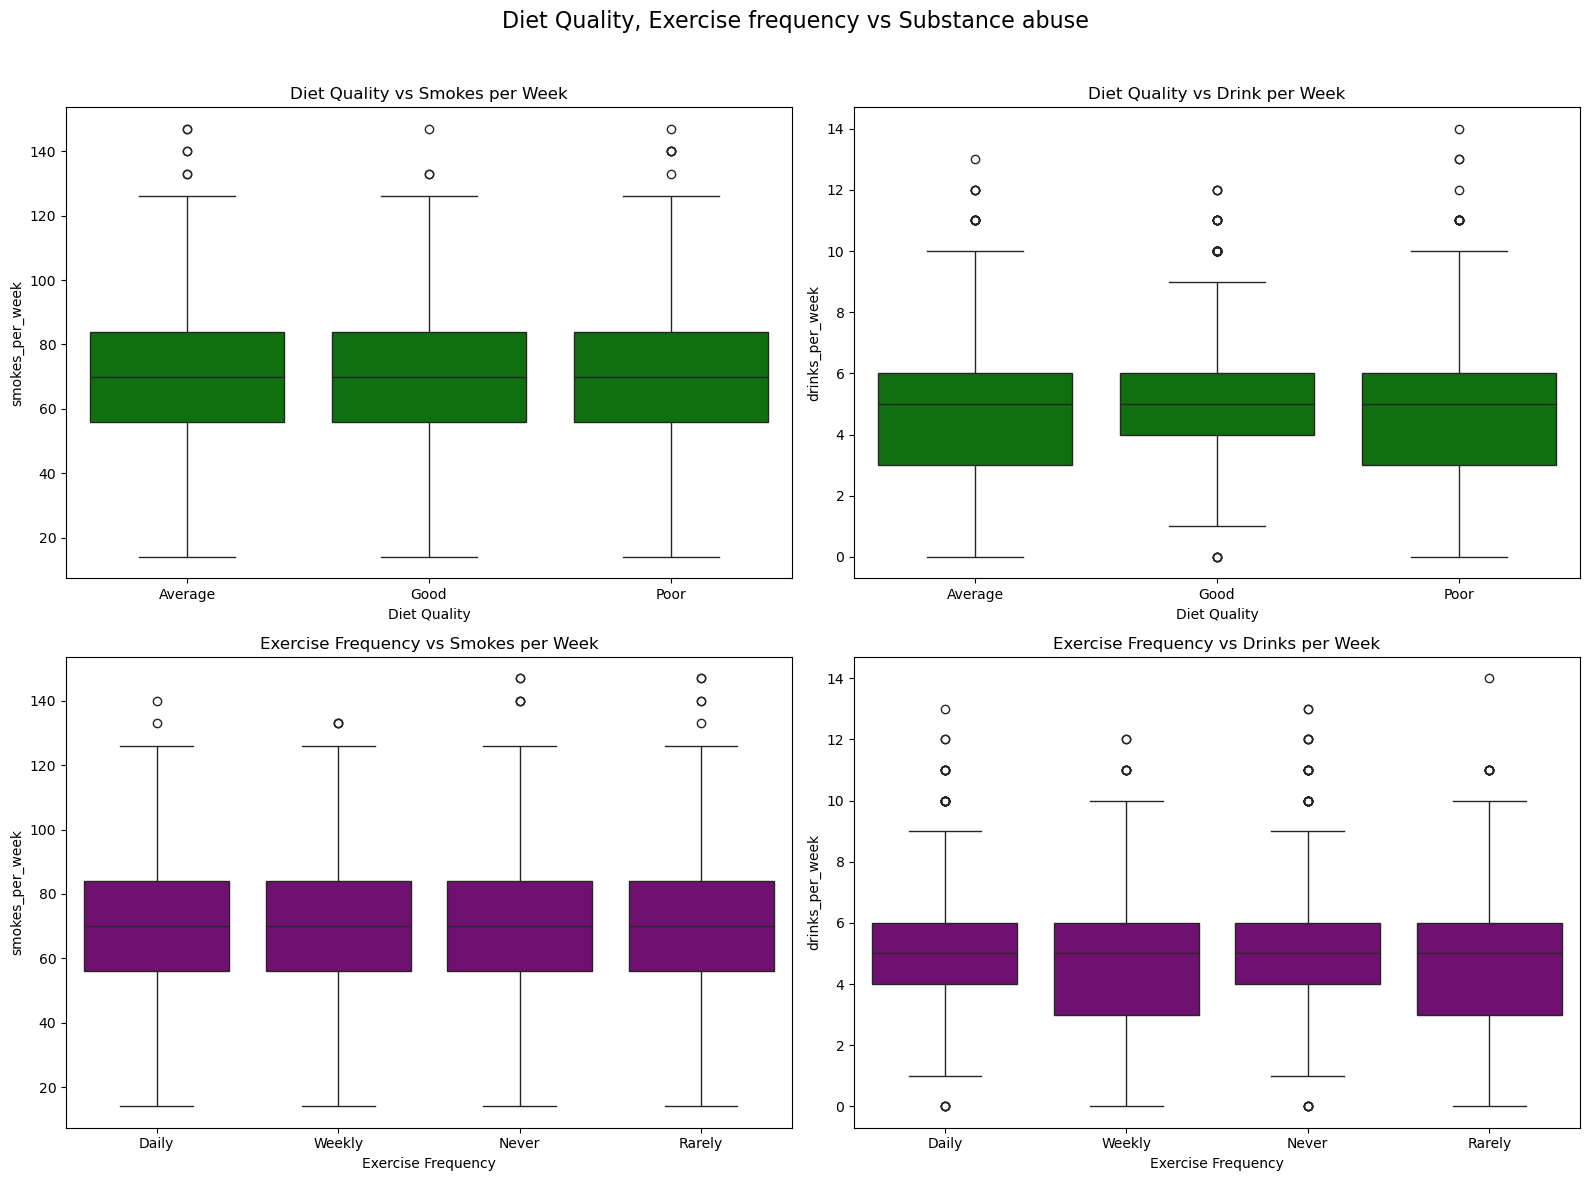

In [68]:
# Setup a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Diet Quality, Exercise frequency vs Substance abuse', fontsize=16)

#  smokes_per_week vs Diet Quality
sb.boxplot(
    data=addiction_copy,
    x='diet_quality',
    y='smokes_per_week',
    color='green',
    ax=axes[0,0]
)
axes[0,0].set_title('Diet Quality vs Smokes per Week')
axes[0,0].set_xlabel('Diet Quality')
axes[0,0].set_ylabel('smokes_per_week')


#  drinks_per_week vs Diet Quality
sb.boxplot(
    data=addiction_copy,
    x='diet_quality',
    y='drinks_per_week',
    color='green',
    ax=axes[0,1]
)
axes[0,1].set_title('Diet Quality vs Drink per Week')
axes[0,1].set_xlabel('Diet Quality')
axes[0,1].set_ylabel('drinks_per_week')


#  smokes_per_week vs Exercise Frequency
sb.boxplot(
    data=addiction_copy,
    x='exercise_frequency',
    y='smokes_per_week',
    color ='purple',
    ax=axes[1,0]
)
axes[1,0].set_title('Exercise Frequency vs Smokes per Week')
axes[1,0].set_xlabel('Exercise Frequency')
axes[1,0].set_ylabel('smokes_per_week')


#  drinks_per_week vs Exercise Frequency
sb.boxplot(
    data=addiction_copy,
    x='exercise_frequency',
    y='drinks_per_week',
    color ='purple',
    ax=axes[1,1]
)
axes[1,1].set_title('Exercise Frequency vs Drinks per Week')
axes[1,1].set_xlabel('Exercise Frequency')
axes[1,1].set_ylabel('drinks_per_week')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

> The analysis shows that diet quality  and exercise frequency has little(constant) effect among smoking individuals, while individuals with poor diet quality tend to drink more. Also, persons who exercise weekly tend to drink less.

#### Analysis between sleep duration vs smoking and drinking habits

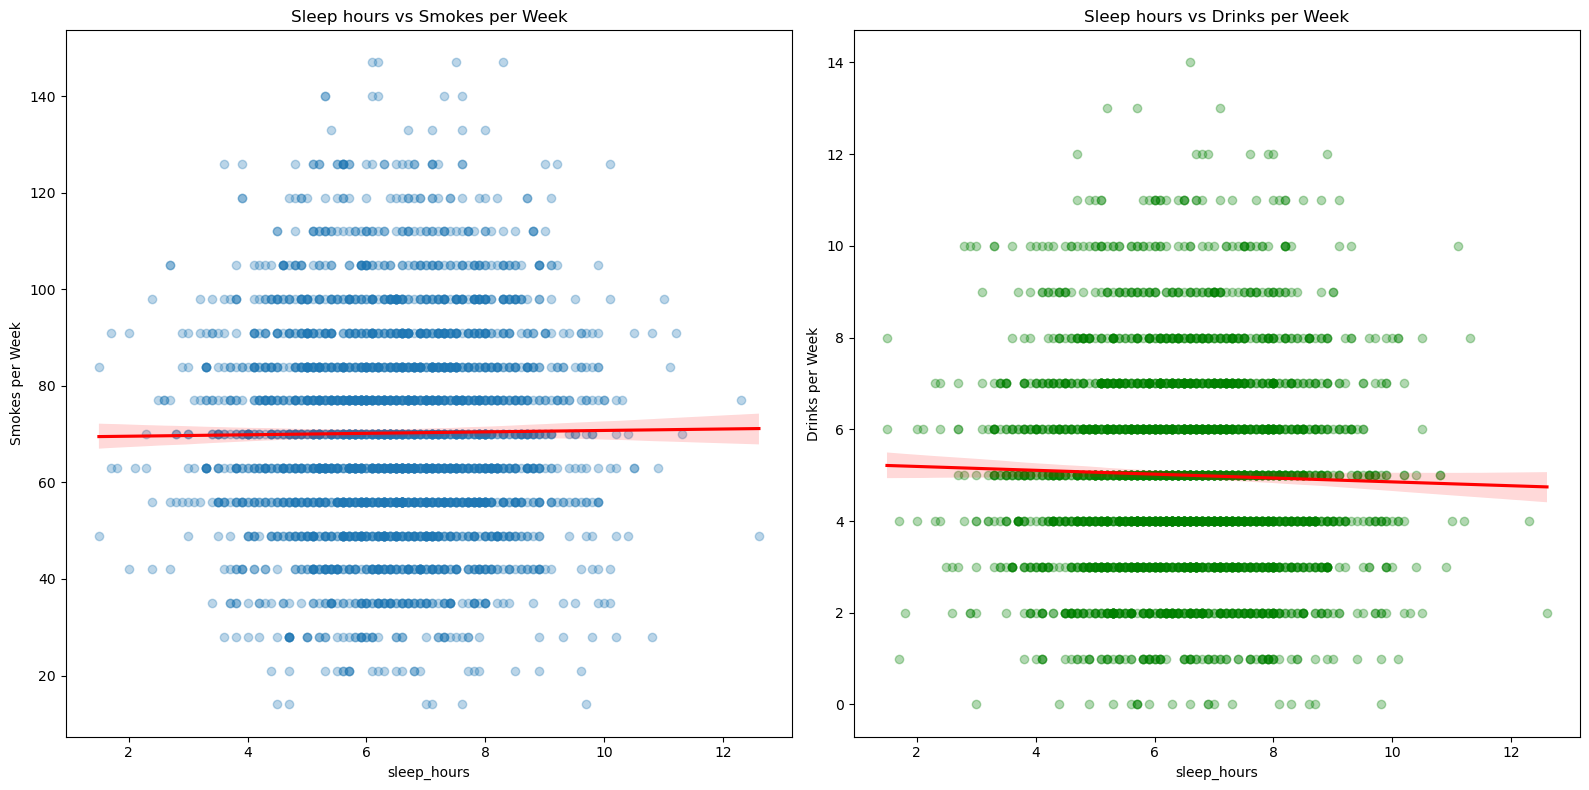

In [71]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- PLOT 1: sleep_hours vs Smokes per Week ---
sb.regplot(
    data=addiction_copy,
    x='sleep_hours',
    y='smokes_per_week',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=axes[0]  
)
axes[0].set_title('Sleep hours vs Smokes per Week')
axes[0].set_xlabel('sleep_hours')
axes[0].set_ylabel('Smokes per Week')

# --- PLOT 2: sleep_hours vs Drinks per Week ---
sb.regplot(
    data=addiction_copy,
    x='sleep_hours',
    y='drinks_per_week',
    scatter_kws={'alpha': 0.3, 'color': 'green'},
    line_kws={'color': 'red'},
    ax=axes[1]  
)
axes[1].set_title('Sleep hours vs Drinks per Week')
axes[1].set_xlabel('sleep_hours')
axes[1].set_ylabel('Drinks per Week')
plt.tight_layout()
plt.show()

> There is no correlation between sleep hours and the number of cigarettes and alcohol consumed smoked per week.

## Section 4 — Behavioural Analysis

#### 4.1 Addiction Onset

In [75]:
#minimum drinking and smoking age
min_age = addiction_copy[['age_started_smoking', 'age_started_drinking']].min()

print('The minimum age for smoking and drinking is:\n', min_age)

The minimum age for smoking and drinking is:
 age_started_smoking     10
age_started_drinking    10
dtype: int64


#### Analysis between age_started_smoking vs smoking habits and age_started_drinking vs drinking habits

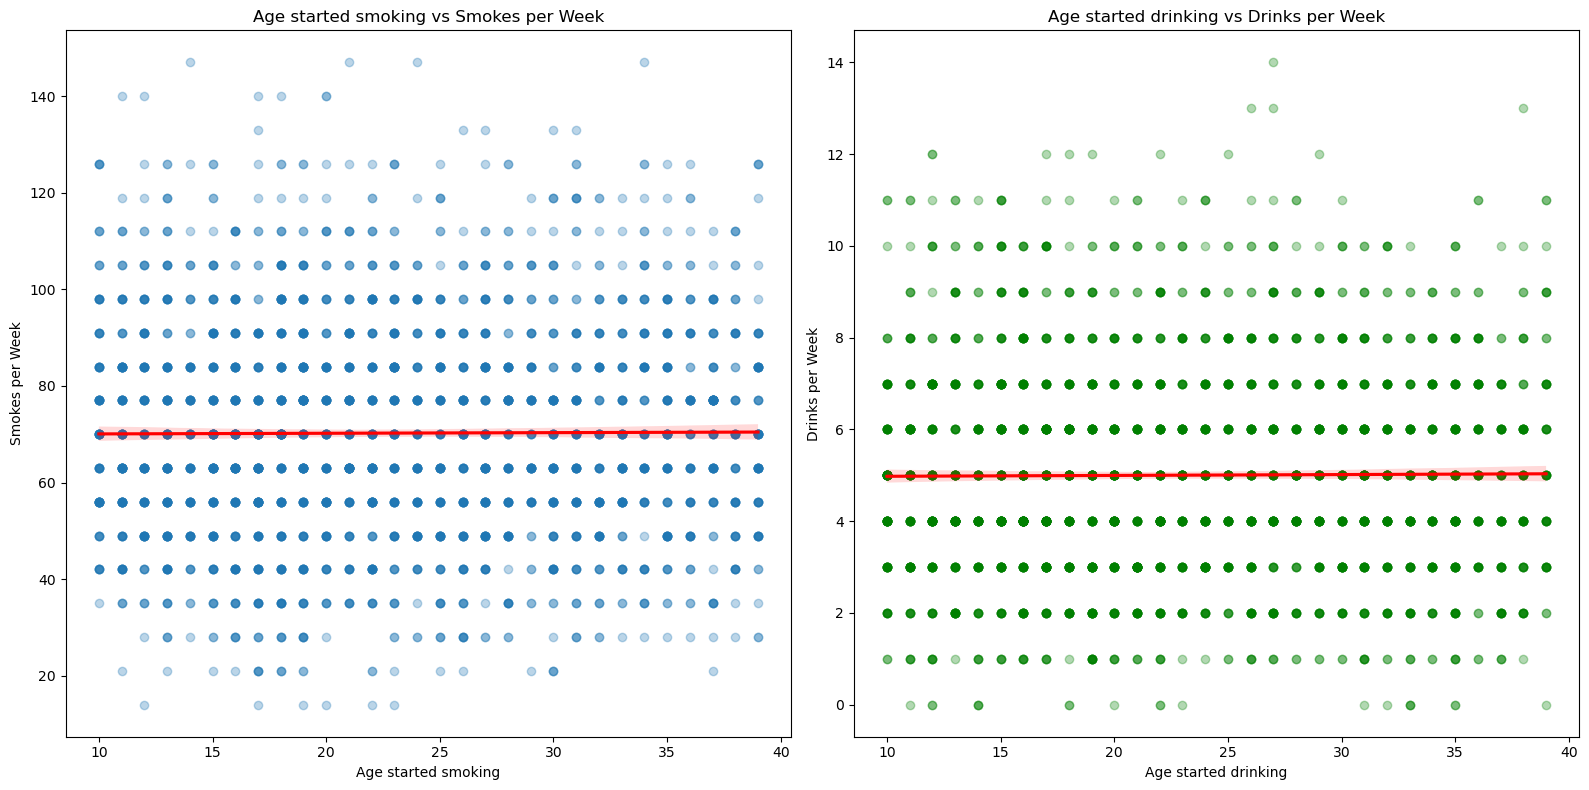

In [77]:
# 1. Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- PLOT 1: Age started smoking vs Smokes per Week ---
sb.regplot(
    data=addiction_copy,
    x='age_started_smoking',
    y='smokes_per_week',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=axes[0]  
)
axes[0].set_title('Age started smoking vs Smokes per Week')
axes[0].set_xlabel('Age started smoking')
axes[0].set_ylabel('Smokes per Week')

# --- PLOT 2: Age started drinking vs Drinks per Week ---
sb.regplot(
    data=addiction_copy,
    x='age_started_drinking',
    y='drinks_per_week',
    scatter_kws={'alpha': 0.3, 'color': 'green'},
    line_kws={'color': 'red'},
    ax=axes[1]  
)
axes[1].set_title('Age started drinking vs Drinks per Week')
axes[1].set_xlabel('Age started drinking')
axes[1].set_ylabel('Drinks per Week')
plt.tight_layout()
plt.show()

> There is no correlation between age started smoking/drinking with amount of alcohol or cigarettes consumed weekly.

#### Analysis between smokes per day and attempts to quit smoking 

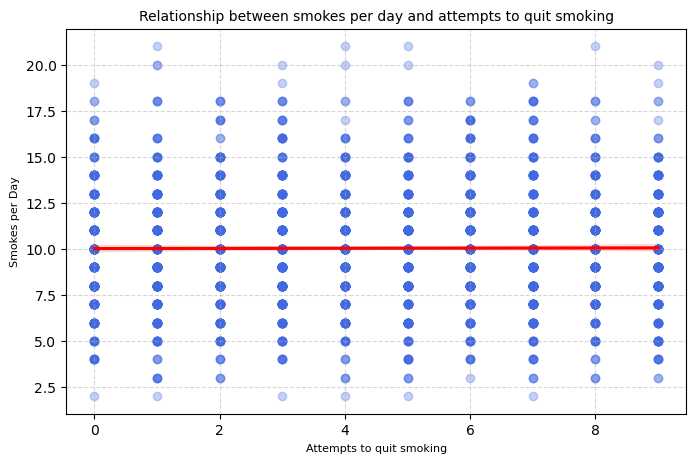

In [80]:
# Create the scatterplot
plt.figure(figsize=[8, 5])

# Using regplot to add a regression line trend
sb.regplot(
    data=addiction_copy, 
    x='attempts_to_quit_smoking', 
    y='smokes_per_day',
    scatter_kws={'alpha':0.3, 'color': 'royalblue'}, 
    line_kws={'color': 'red'} 
)

# Add labels
plt.title('Relationship between smokes per day and attempts to quit smoking', fontsize=10)
plt.xlabel('Attempts to quit smoking', fontsize=8)
plt.ylabel('Smokes per Day', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

> There is no relationship between the number of attempts to quit smoking and the number of cigarettes smoked per day.

#### 4.2 Mental health relationship

#### Analysis between mental health status and substance abuse

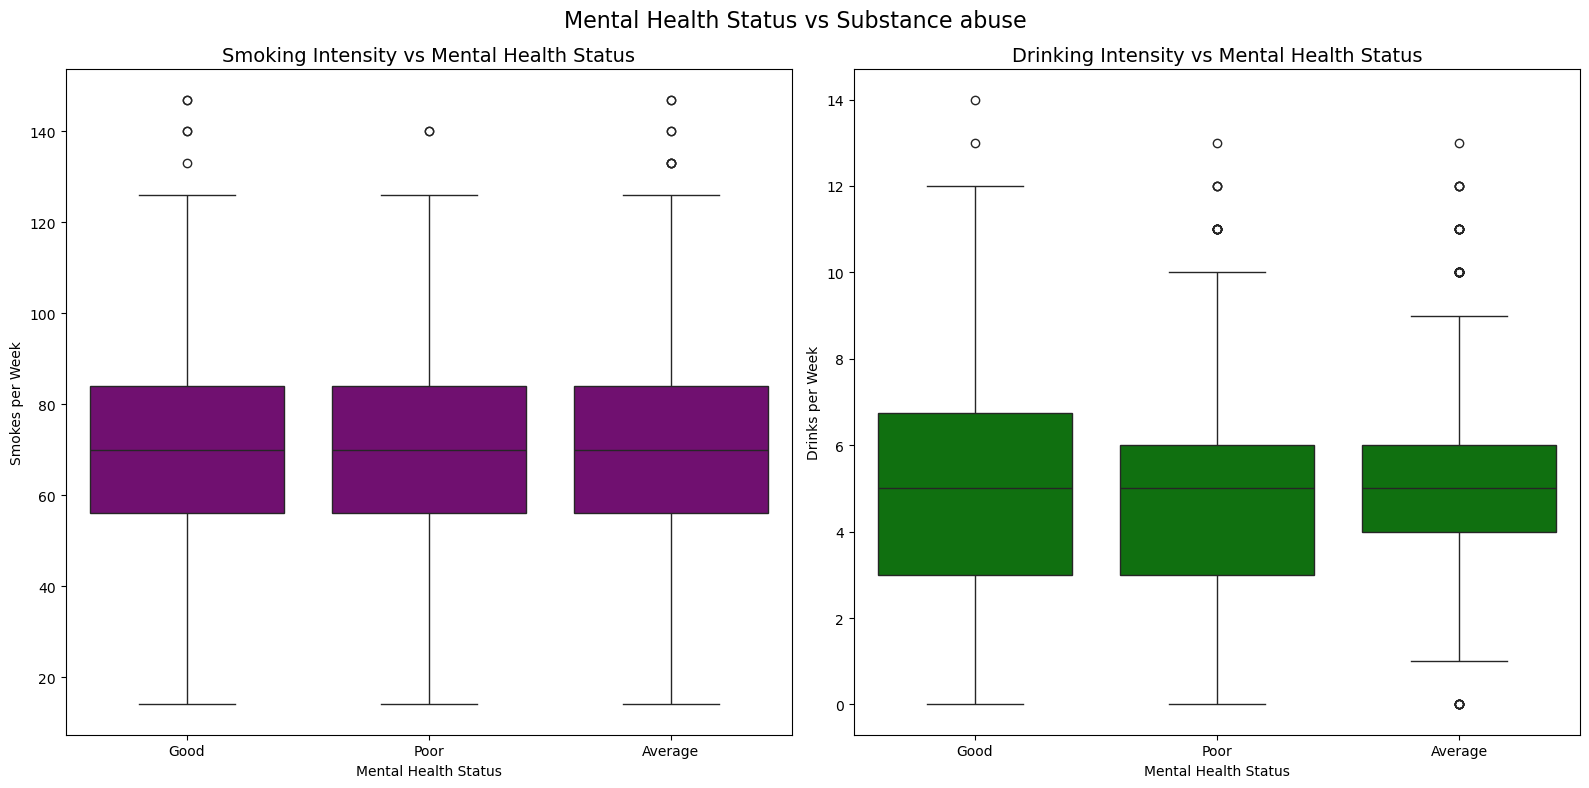

In [84]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Mental Health Status vs Substance abuse', fontsize=16)

# PLOT 1: Menthal Health vs Smokes
sb.boxplot(
    data=addiction_copy,
    x='mental_health_status', 
    y='smokes_per_week',    
    color='purple',
    ax=axes[0]                
)
axes[0].set_title('Smoking Intensity vs Mental Health Status', fontsize=14)
axes[0].set_xlabel('Mental Health Status')
axes[0].set_ylabel('Smokes per Week')

# PLOT 2: Mental Health vs Drinks
sb.boxplot(
    data=addiction_copy,
    x='mental_health_status', 
    y='drinks_per_week', 
    color='green',
    ax=axes[1]                
)
axes[1].set_title('Drinking Intensity vs Mental Health Status', fontsize=14)
axes[1].set_xlabel('Mental Health Status')
axes[1].set_ylabel('Drinks per Week')
plt.tight_layout()
plt.show()

> Based on the data in this chart, there is no meaningful difference in smoking intensity between mental health groups. All three groups show nearly identical ranges of cigarettes smoked per week .

> Drinking patterns show more variation by mental health status than smoking patterns. This chart shows that persons with "Good" mental health tend to drink more which is logically conflicting and needs to be further investigated.

## Section 5 — Health Impact Analysis

#### 5.1 BMI vs Lifestyle

#### Analysis between bmi vs smokes per week, drinks per week, excerise frequency and diet quality

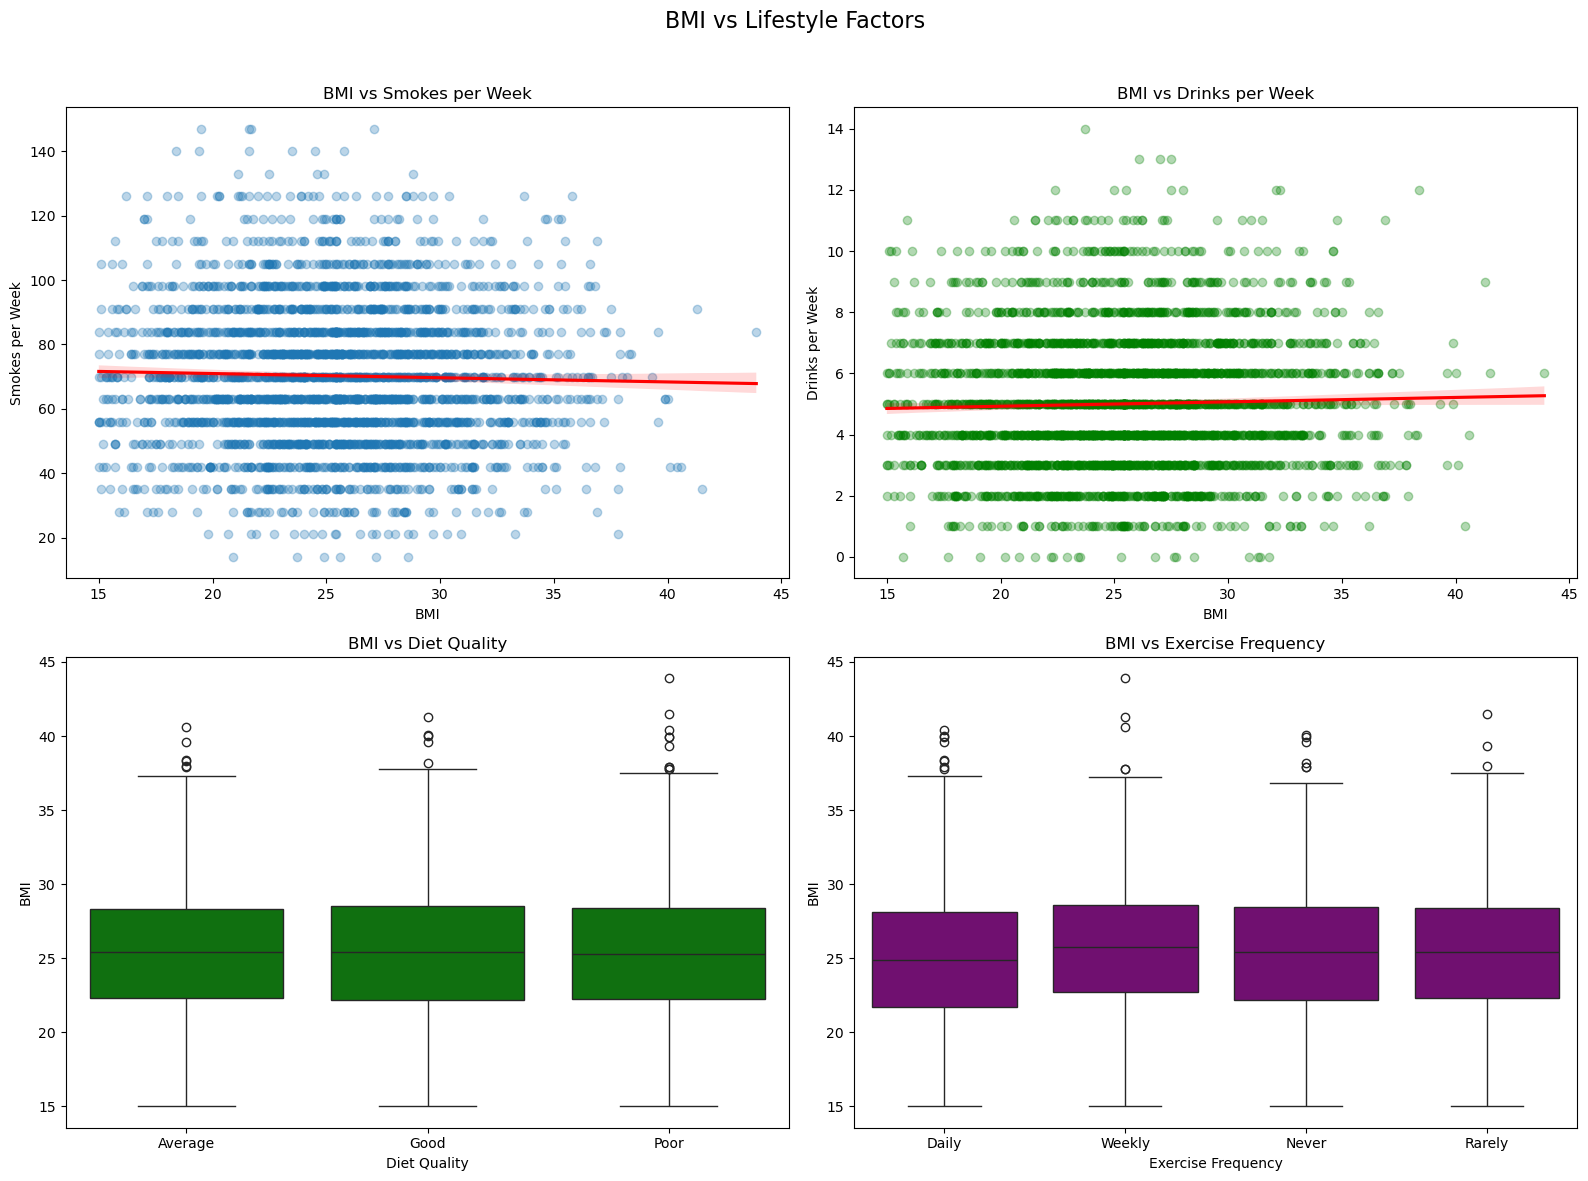

In [89]:
# Setup a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BMI vs Lifestyle Factors', fontsize=16)

# --- PLOT 1: BMI vs Smokes per Week (Scatterplot) ---
sb.regplot(
    data=addiction_copy,
    x='bmi',
    y='smokes_per_week',
    ax=axes[0, 0],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

axes[0,0].set_title('BMI vs Smokes per Week')
axes[0,0].set_xlabel('BMI')
axes[0,0].set_ylabel('Smokes per Week')

# --- Scatterplot: BMI vs Drinks per Week ---
sb.regplot(
    data=addiction_copy,
    x='bmi',
    y='drinks_per_week',
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.3, 'color': 'green'},
    line_kws={'color': 'red'}
)
axes[0,1].set_title('BMI vs Drinks per Week')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Drinks per Week')

# --- boxplot: BMI vs Diet Quality ---
sb.boxplot(
    data=addiction_copy,
    x='diet_quality',
    y='bmi',
    color='green',
    ax=axes[1,0]
)
axes[1,0].set_title('BMI vs Diet Quality')
axes[1,0].set_xlabel('Diet Quality')
axes[1,0].set_ylabel('BMI')

# --- boxplot: BMI vs Exercise Frequency ---
sb.boxplot(
    data=addiction_copy,
    x='exercise_frequency',
    y='bmi',
    color ='purple',
    ax=axes[1,1]
)
axes[1,1].set_title('BMI vs Exercise Frequency')
axes[1,1].set_xlabel('Exercise Frequency')
axes[1,1].set_ylabel('BMI')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

> Based on the data in this chart, BMI has no relationship with either smoking or drinking intensity; both smoking and drinking consumption are static regardless of changes in body mass index.

> Individuals with poor diet quality have higher bmi while exercise frequency is fairly constant across bmi levels.

#### 5.2 Sleep Analysis

#### Analysis between sleep duration vs smoking and drinking

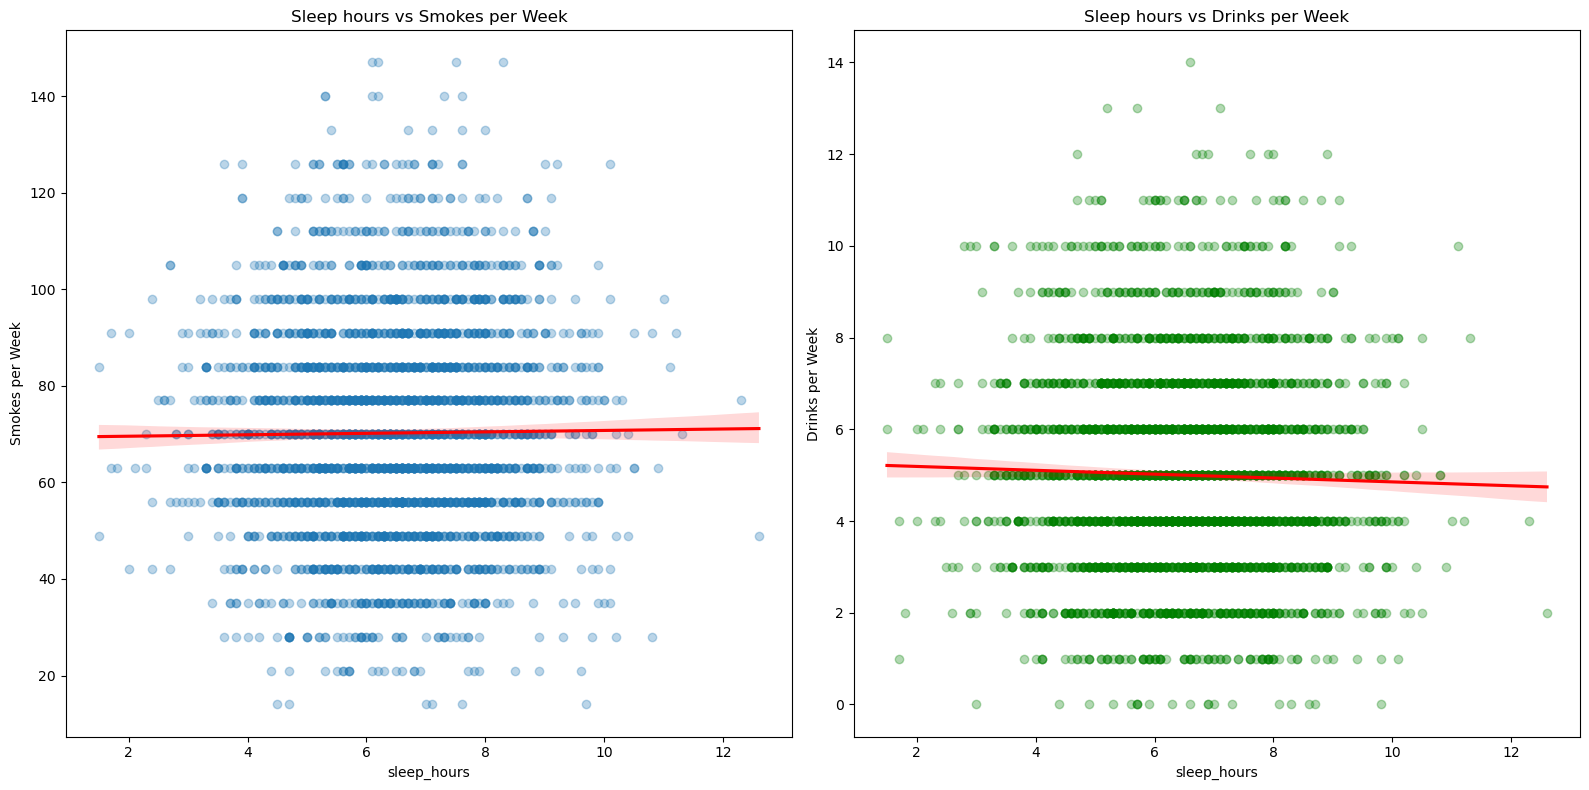

In [93]:
# Setup the figure for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- PLOT 1: sleep_hours vs Smokes per Week ---
sb.regplot(
    data=addiction_copy,
    x='sleep_hours',
    y='smokes_per_week',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=axes[0]  
)
axes[0].set_title('Sleep hours vs Smokes per Week')
axes[0].set_xlabel('sleep_hours')
axes[0].set_ylabel('Smokes per Week')

# --- PLOT 2: sleep_hours vs Drinks per Week ---
sb.regplot(
    data=addiction_copy,
    x='sleep_hours',
    y='drinks_per_week',
    scatter_kws={'alpha': 0.3, 'color': 'green'},
    line_kws={'color': 'red'},
    ax=axes[1]  
)
axes[1].set_title('Sleep hours vs Drinks per Week')
axes[1].set_xlabel('sleep_hours')
axes[1].set_ylabel('Drinks per Week')
plt.tight_layout()
plt.show()

> The scatterplot shows a horizontal distribution of points, indicating no relationship between sleep hours and the number of cigarettes smoked or alcohol consumed per week

##### Heatmap of numeric variables

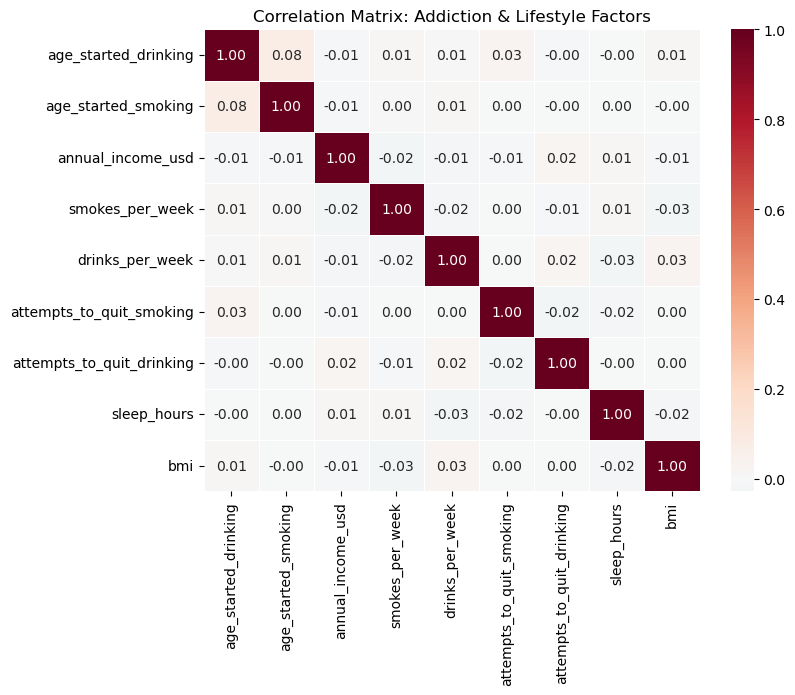

In [146]:
# Select the specific columns for analysis
heatmap_cols = [
    'age_started_drinking', 'age_started_smoking', 'annual_income_usd', 
    'smokes_per_week', 'drinks_per_week', 'attempts_to_quit_smoking', 
    'attempts_to_quit_drinking', 'sleep_hours', 'bmi'
]

# Calculate the correlation matrix
corr_matrix = addiction_copy[heatmap_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sb.heatmap(
    corr_matrix, 
    annot=True,         
    cmap='RdBu_r',       
    center=0,            
    fmt='.2f',          
    linewidths=0.5)

plt.title('Correlation Matrix: Addiction & Lifestyle Factors', fontsize=12)
plt.show()

> There is a weak positive correlation between age started smoking and age started drinking.

In [95]:
# Save the cleaned dataframe to a new CSV file
addiction_copy.to_csv('addiction_clean.csv', index=False)

## Section 6 — Insights and Recommendations

This analysis shows that addiction stems from a complex mix of social, cultural, psychological, behavioral, and lifestyle factors rather than isolated demographic traits. Smoking behavior remains largely uniform across BMI, sleep duration, mental health status, and exercise frequency suggesting either a genuine lack of correlation or insufficient data diversity on the sample population. 

Alcohol consumption displays a clearer connection to mental health status. Variations in drinking patterns across mental health groups suggest psychological factors play a more significant role in alcohol use, positioning mental health as a critical intervention point for addressing problematic drinking.

Korea, Congo and Saudi Arabia need a change in their social and cultural habits due to their high substance abuse profiles.

These findings are constrained by data limitations, including low variability in key lifestyle variables. Future data collection should prioritize data validation strategies and diverse populations to enable more robust analysis.

From a policy perspective, interventions should shift from broad demographic targeting to addressing social, cultural, behavioral and psychological drivers. Early prevention for youth aged 10–15 is essential, alongside integrating mental health services into addiction management. Lifestyle modifications like diet and exercise remain valuable health improvement choices but not primary solutions.

In conclusion, addiction is best understood as a multifaceted issue requiring early intervention, integrated mental health care, and data-driven strategies.